In [22]:
# Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

# Regression Models

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    LogisticRegression
)

from sklearn.tree import (
    DecisionTreeRegressor,
    DecisionTreeClassifier
)

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    GradientBoostingRegressor
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB

# Metrics

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)

# Clustering

from sklearn.cluster import (
    KMeans,
    DBSCAN
)

from sklearn.decomposition import PCA

# Step 1: Load Dataset

In [23]:
df = pd.read_csv("AmesHousing.csv")

df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# Step 2: Initial Inspection

In [24]:
print(df.shape)

df.info()

df.isnull().sum().sort_values(ascending=False).head(20)

(2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  Hou

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Finish      159
Garage Yr Blt      159
Garage Qual        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
dtype: int64

# Step 3: Drop Unnecessary Columns

In [25]:
df.drop(columns=["Order","PID"], inplace=True, errors="ignore")

# Step 4: Create Classification Target


In [26]:
median_price = df["SalePrice"].median()

df["HighPrice"] = np.where(
    df["SalePrice"] > median_price,
    1,
    0
)

df["HighPrice"].value_counts()

HighPrice
0    1467
1    1463
Name: count, dtype: int64

# Step 5: Separate Features and Targets

In [27]:
X = df.drop(
    columns=["SalePrice","HighPrice"]
)

y_reg = df["SalePrice"]

y_clf = df["HighPrice"]

# Step 6: Identify Numerical and Categorical Features

In [28]:
numeric_features = X.select_dtypes(
    include=np.number
).columns

categorical_features = X.select_dtypes(
    exclude=np.number
).columns

# Step 7: Preprocessing Pipeline

In [29]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Step 8: Train Test Split for Regression

In [30]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Step 9: Regression Models

In [31]:
regression_models = {

    "Linear Regression": LinearRegression(),

    "Ridge": Ridge(),

    "Lasso": Lasso(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [32]:
reg_results = []

for name, model in regression_models.items():

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipe.fit(
        X_train_reg,
        y_train_reg
    )

    pred = pipe.predict(X_test_reg)

    r2 = r2_score(
        y_test_reg,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_reg,
            pred
        )
    )

    mae = mean_absolute_error(
        y_test_reg,
        pred
    )

    cv = cross_val_score(
        pipe,
        X,
        y_reg,
        cv=5,
        scoring="r2"
    ).mean()

    reg_results.append([
        name,
        r2,
        rmse,
        mae,
        cv
    ])

reg_df = pd.DataFrame(
    reg_results,
    columns=[
        "Model",
        "R2",
        "RMSE",
        "MAE",
        "CV_R2"
    ]
)

reg_df.sort_values(
    "R2",
    ascending=False
)

c:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.587e+10, tolerance: 1.394e+09
  model = cd_fast.sparse_enet_coordinate_descent(
c:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.936e+09, tolerance: 1.414e+09
  model = cd_fast.sparse_enet_coordinate_descent(
c:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.314e+11, tolerance: 1.534e+09
  model =

,Model,R2,RMSE,MAE,CV_R2
4,Random Forest,0.913479,26337.947995,15732.023549,0.884876
5,Gradient Boosting,0.912280,26519.750549,15191.720273,0.908807
1,Ridge,0.895884,28892.166563,16185.578656,0.869562
2,Lasso,0.894277,29114.199921,15794.950494,0.863722
0,Linear Regression,0.890614,29614.331834,16007.107601,0.859275
3,Decision Tree,0.838421,35992.559657,24169.733788,0.764767


# Step 10: Classification Models

In [33]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

In [34]:
classification_models = {

    "Logistic Regression":
    LogisticRegression(max_iter=5000),

    "KNN":
    KNeighborsClassifier(),

    "Decision Tree":
    DecisionTreeClassifier(),

    "Random Forest":
    RandomForestClassifier(),

    "SVM":
    SVC(),

    "Naive Bayes":
    GaussianNB()
}

In [36]:
if name == "Naive Bayes":

    X_processed = preprocessor.fit_transform(X)

    # Convert sparse to dense
    X_processed = X_processed.toarray()

    scores = cross_val_score(
        model,
        X_processed,
        y_clf,
        cv=5,
        scoring="accuracy"
    )

    clf_results.append(
        [name, scores.mean()]
    )

# Step 10: Classification Model Evaluation

In this section, we evaluate classification models using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

The target variable is **HighPrice**, where:

- 1 = House price above median
- 0 = House price below or equal to median

In [37]:
# Train Best Classification Model

best_classifier = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

best_classifier.fit(X_train_cls, y_train_cls)

y_pred_cls = best_classifier.predict(X_test_cls)

print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))
print("Precision:", precision_score(y_test_cls, y_pred_cls))
print("Recall:", recall_score(y_test_cls, y_pred_cls))
print("F1 Score:", f1_score(y_test_cls, y_pred_cls))

Accuracy: 0.9300341296928327
Precision: 0.9344827586206896
Recall: 0.9249146757679181
F1 Score: 0.9296740994854202


# Classification Report

The classification report provides:

- Precision
- Recall
- F1-score
- Support

for each class.

In [38]:
print(classification_report(y_test_cls, y_pred_cls))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93       293
           1       0.93      0.92      0.93       293

    accuracy                           0.93       586
   macro avg       0.93      0.93      0.93       586
weighted avg       0.93      0.93      0.93       586



# Confusion Matrix

The confusion matrix helps identify:

- True Positives
- True Negatives
- False Positives
- False Negatives

This allows us to evaluate model performance beyond simple accuracy.

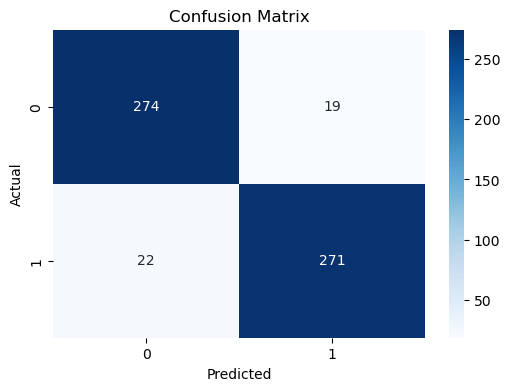

In [39]:
cm = confusion_matrix(y_test_cls, y_pred_cls)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Step 11: Feature Importance Analysis

Tree-based models can identify the most important features influencing house prices.

We use Random Forest Regressor feature importance values.

In [40]:
rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_model.fit(X_train_reg, y_train_reg)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
feature_names = rf_model.named_steps[
    "prep"
].get_feature_names_out()

importances = rf_model.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
3,num__Overall Qual,0.601529
15,num__Gr Liv Area,0.105499
12,num__1st Flr SF,0.034465
11,num__Total Bsmt SF,0.026885
13,num__2nd Flr SF,0.023098
8,num__BsmtFin SF 1,0.022523
18,num__Full Bath,0.016963
2,num__Lot Area,0.015261
25,num__Garage Cars,0.014970
26,num__Garage Area,0.014488


# Top 15 Most Important Features

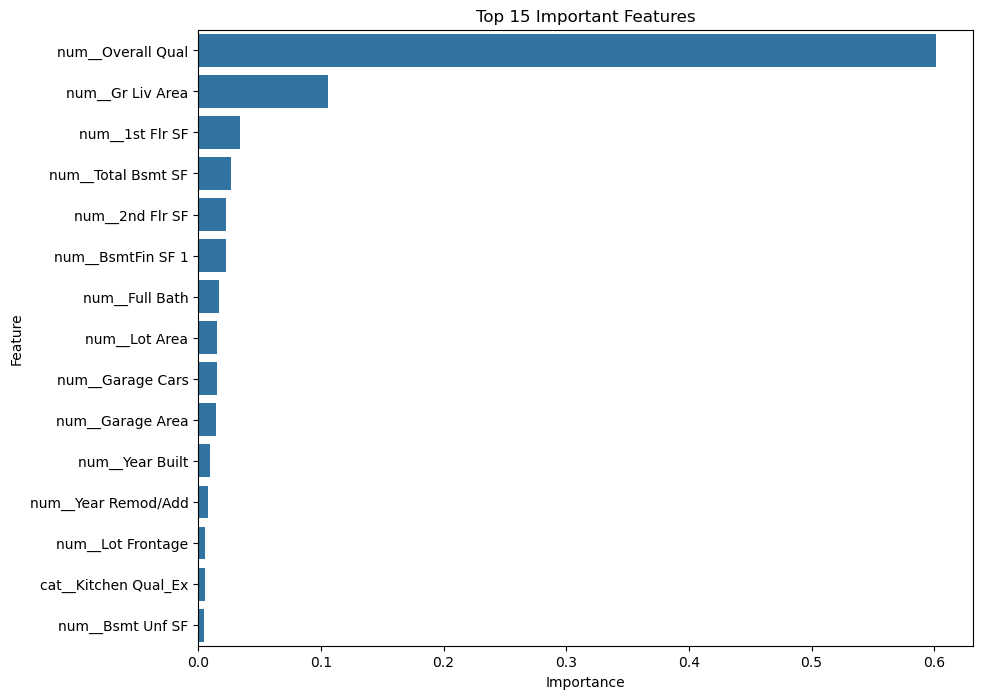

In [42]:
top_features = importance_df.head(15)

plt.figure(figsize=(10,8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 15 Important Features")
plt.show()

# Step 12: Correlation Analysis

We examine relationships between important numerical variables and SalePrice.

In [43]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

sale_corr = corr["SalePrice"].sort_values(
    ascending=False
)

sale_corr.head(20)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
HighPrice         0.702148
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Lot Frontage      0.357318
Wood Deck SF      0.327143
Open Porch SF     0.312951
Half Bath         0.285056
Name: SalePrice, dtype: float64

# Correlation Heatmap

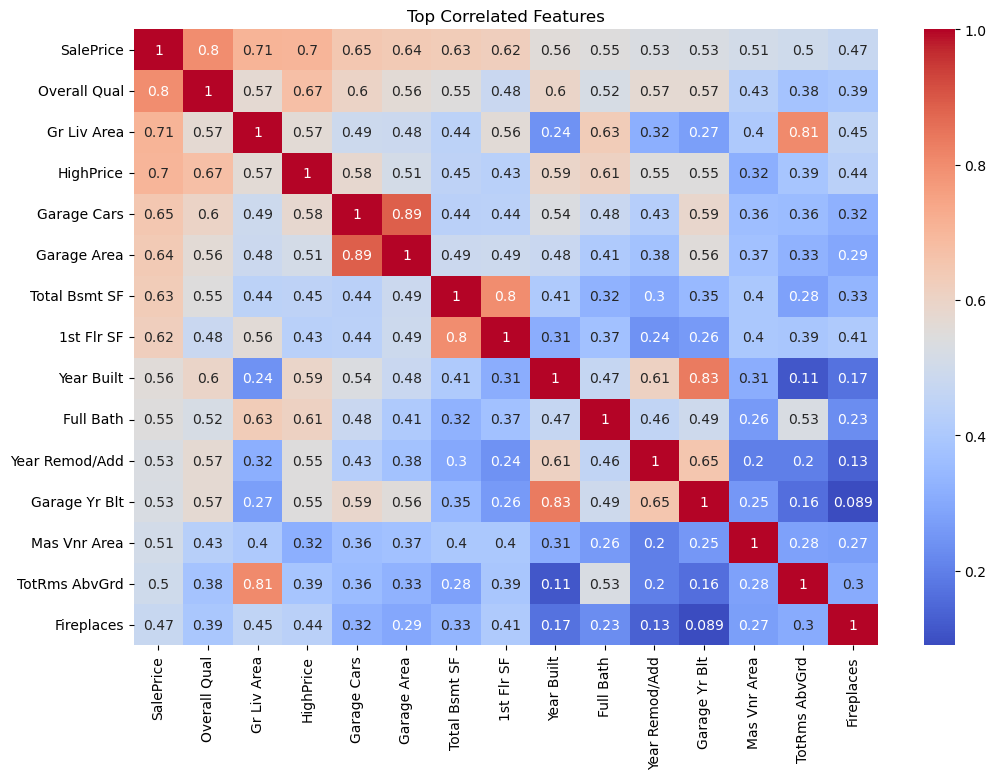

In [44]:
top_corr_features = sale_corr.head(15).index

plt.figure(figsize=(12,8))

sns.heatmap(
    df[top_corr_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Top Correlated Features")
plt.show()

# Step 13: Clustering Analysis

Clustering helps identify groups of similar houses without using target labels.

Algorithms used:

- K-Means
- DBSCAN

In [45]:
cluster_features = [

    "Overall Qual",
    "Gr Liv Area",
    "Total Bsmt SF",
    "Year Built",
    "Garage Cars",
    "SalePrice"
]

cluster_data = df[cluster_features].copy()

In [46]:
scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(
    cluster_data
)

In [48]:
cluster_data.isnull().sum()

Overall Qual     0
Gr Liv Area      0
Total Bsmt SF    1
Year Built       0
Garage Cars      1
SalePrice        0
dtype: int64

In [49]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "Overall Qual",
    "Gr Liv Area",
    "Total Bsmt SF",
    "Year Built",
    "Garage Cars",
    "SalePrice"
]

cluster_data = df[cluster_features].copy()

# Handle missing values
imputer = SimpleImputer(strategy="median")

cluster_imputed = imputer.fit_transform(
    cluster_data
)

# Scale data
scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(
    cluster_imputed
)

In [50]:
import numpy as np

print(np.isnan(cluster_scaled).sum())

0


# K-Means Clustering

In [51]:
silhouette_scores = []

for k in range(2,6):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        cluster_scaled
    )

    score = silhouette_score(
        cluster_scaled,
        labels
    )

    silhouette_scores.append(
        [k, score]
    )

silhouette_df = pd.DataFrame(
    silhouette_scores,
    columns=["K","Silhouette Score"]
)

silhouette_df

,K,Silhouette Score
0,2,0.348832
1,3,0.285215
2,4,0.237889
3,5,0.219700


# Step 15: Compare Clusters with Sale Price

We compare average house prices across clusters to determine whether clustering has identified meaningful market segments.

In [53]:
print(cluster_data.columns)

Index(['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Year Built',
       'Garage Cars', 'SalePrice'],
      dtype='object')


In [54]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(cluster_scaled)

cluster_data["Cluster"] = clusters

print(cluster_data.head())

   Overall Qual  Gr Liv Area  Total Bsmt SF  Year Built  Garage Cars  \
0             6         1656         1080.0        1960          2.0   
1             5          896          882.0        1961          1.0   
2             6         1329         1329.0        1958          1.0   
3             7         2110         2110.0        1968          2.0   
4             5         1629          928.0        1997          2.0   

   SalePrice  Cluster  
0     215000        2  
1     105000        0  
2     172000        0  
3     244000        1  
4     189900        2  


In [55]:
print(cluster_data.columns)

Index(['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Year Built',
       'Garage Cars', 'SalePrice', 'Cluster'],
      dtype='object')


In [56]:
cluster_price_summary = cluster_data.groupby(
    "Cluster"
)["SalePrice"].agg(
    ["count", "mean", "median", "min", "max"]
)

cluster_price_summary

,count,mean,median,min,max
Cluster,,,,,
0,1250,123568.186400,126000.0,12789,260000
1,477,317631.293501,298236.0,147000,755000
2,1203,186003.404821,182900.0,82500,330000


# Step 15: Cluster Profile Analysis

We analyze the characteristics of each cluster by calculating average values of key housing features.

This helps us understand whether clusters represent low-value, mid-range, or premium houses.

In [57]:
cluster_profiles = cluster_data.groupby("Cluster").mean()

cluster_profiles

,Overall Qual,Gr Liv Area,Total Bsmt SF,Year Built,Garage Cars,SalePrice
Cluster,,,,,,
0,5.014400,1209.633600,820.094476,1946.504000,1.147318,123568.186400
1,8.134172,2143.903564,1602.989518,1998.352201,2.691824,317631.293501
2,6.408978,1545.643392,1073.362427,1986.475478,2.043225,186003.404821


# Cluster Feature Comparison

The following visualization compares average feature values across clusters.

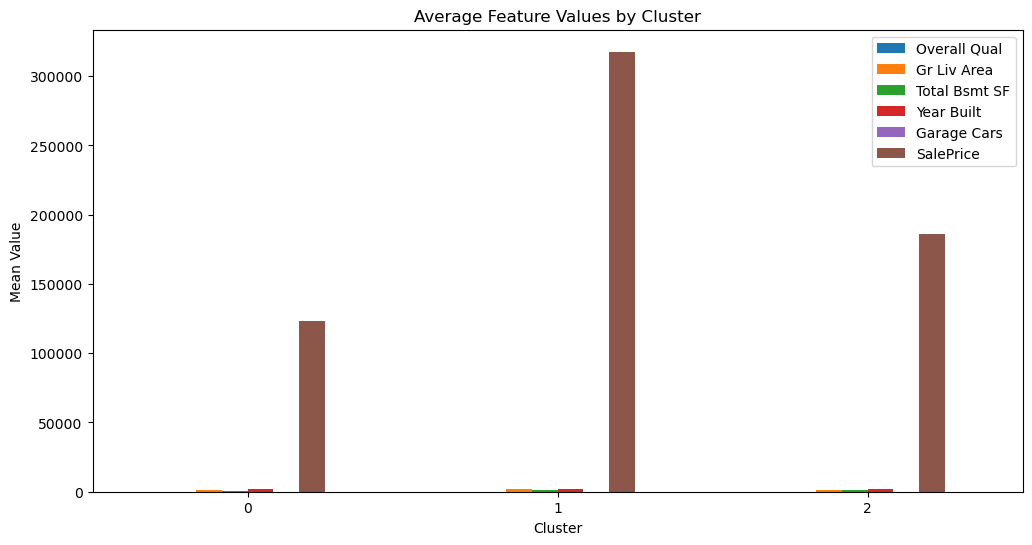

In [58]:
cluster_profiles.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Average Feature Values by Cluster")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)

plt.show()

# Step 16: Cluster Size Analysis

We examine how many houses belong to each cluster.

In [59]:
cluster_data["Cluster"].value_counts()

Cluster
0    1250
2    1203
1     477
Name: count, dtype: int64

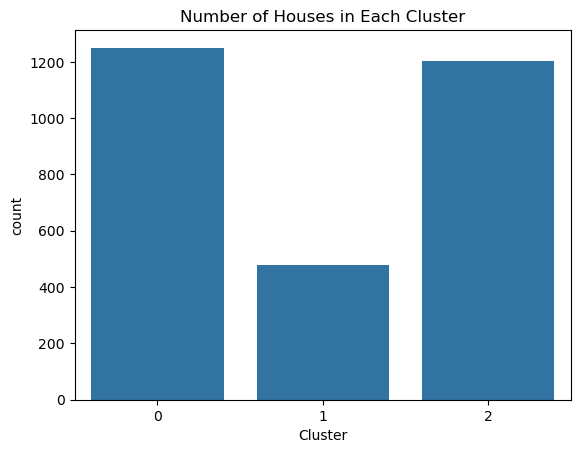

In [60]:
sns.countplot(
    x="Cluster",
    data=cluster_data
)

plt.title("Number of Houses in Each Cluster")

plt.show()

# Step 17: Compare Clusters with HighPrice Category

We compare cluster membership with the HighPrice classification target to determine whether clustering discovered meaningful price segments.

In [61]:
cluster_vs_price = pd.crosstab(
    cluster_data["Cluster"],
    df["HighPrice"]
)

cluster_vs_price

HighPrice,0,1
Cluster,,
0,1165,85
1,3,474
2,299,904


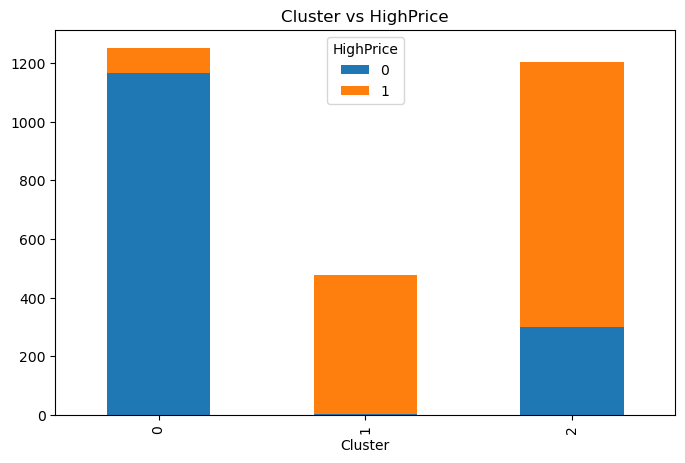

In [62]:
cluster_vs_price.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Cluster vs HighPrice")

plt.show()

# Step 18: Neighborhood Analysis

Location is one of the strongest drivers of housing prices.

We calculate average sale prices by neighborhood.

In [63]:
neighborhood_prices = (
    df.groupby("Neighborhood")["SalePrice"]
    .mean()
    .sort_values(ascending=False)
)

neighborhood_prices.head(10)

Neighborhood
NoRidge    330319.126761
StoneBr    324229.196078
NridgHt    322018.265060
GrnHill    280000.000000
Veenker    248314.583333
Timber     246599.541667
Somerst    229707.324176
ClearCr    208662.090909
Crawfor    207550.834951
CollgCr    201803.434457
Name: SalePrice, dtype: float64

In [64]:
print("Highest Average Price Neighborhood:")
print(neighborhood_prices.idxmax())

print("\nLowest Average Price Neighborhood:")
print(neighborhood_prices.idxmin())

Highest Average Price Neighborhood:
NoRidge

Lowest Average Price Neighborhood:
MeadowV


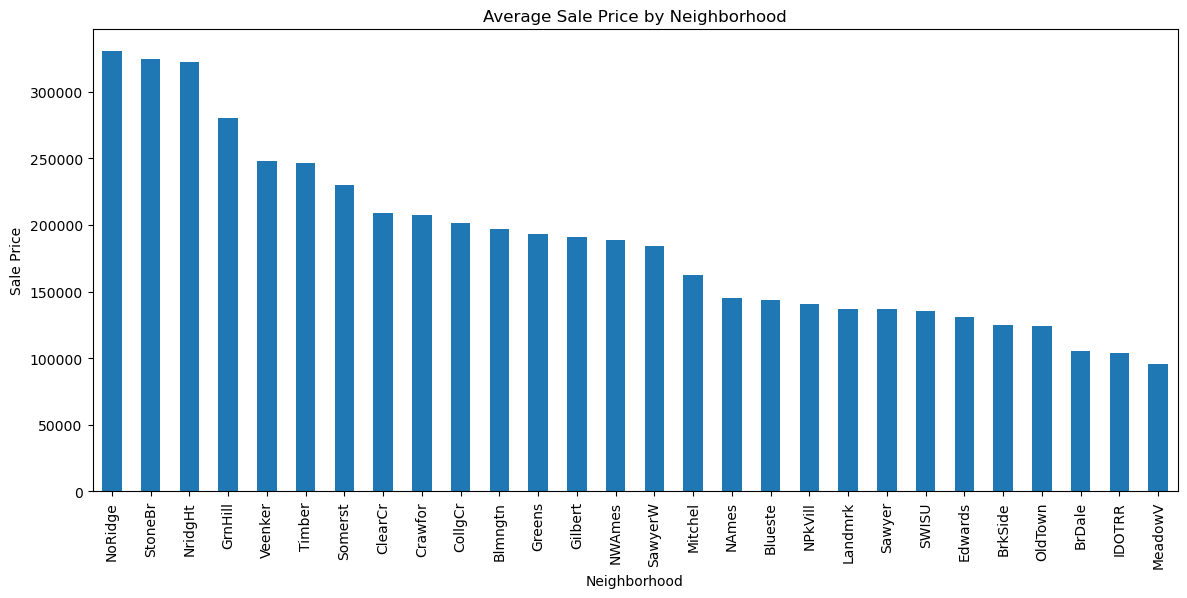

In [65]:
plt.figure(figsize=(14,6))

neighborhood_prices.plot(
    kind="bar"
)

plt.title("Average Sale Price by Neighborhood")

plt.ylabel("Sale Price")

plt.show()

# Step 19: Relationship Between Overall Quality and Sale Price

We investigate whether higher quality homes sell for higher prices.

In [66]:
print(
    "Correlation:",
    df["Overall Qual"].corr(df["SalePrice"])
)

Correlation: 0.7992617947690227


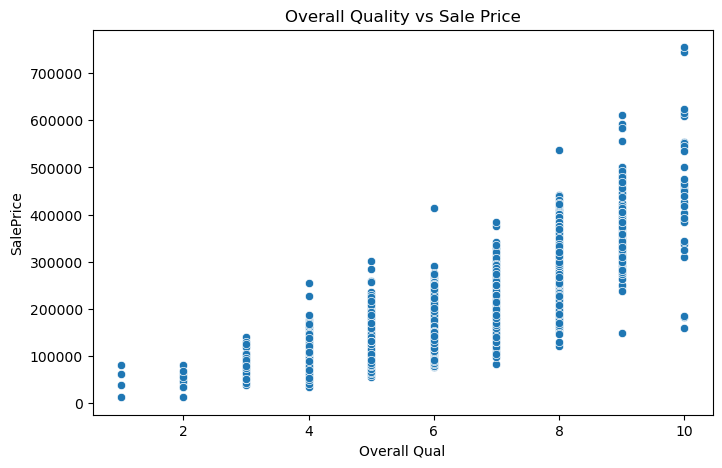

In [67]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Overall Qual",
    y="SalePrice"
)

plt.title("Overall Quality vs Sale Price")

plt.show()

# Step 20: Relationship Between Living Area and Sale Price

We investigate whether larger houses sell for higher prices.

In [68]:
print(
    "Correlation:",
    df["Gr Liv Area"].corr(df["SalePrice"])
)

Correlation: 0.7067799209766279


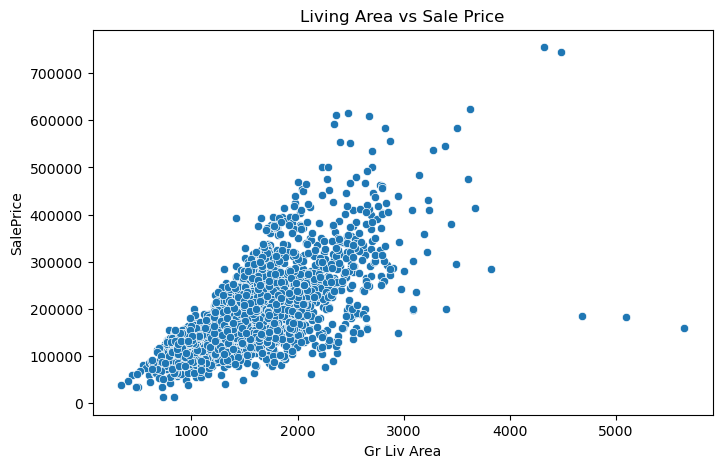

In [69]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Gr Liv Area",
    y="SalePrice"
)

plt.title("Living Area vs Sale Price")

plt.show()

# Step 21: House Age Analysis

We examine whether newer houses sell for higher prices.

In [70]:
print(
    "Year Built Correlation:",
    df["Year Built"].corr(df["SalePrice"])
)

Year Built Correlation: 0.5584261057120454


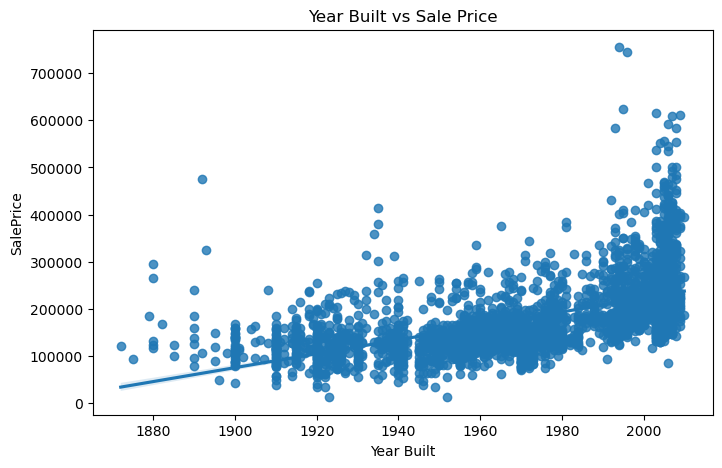

In [71]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Year Built",
    y="SalePrice"
)

plt.title("Year Built vs Sale Price")

plt.show()

# Step 22: Garage Analysis

We investigate whether garage size influences house prices.

In [72]:
garage_cols = [
    "Garage Cars",
    "Garage Area",
    "SalePrice"
]

df[garage_cols].corr()

,Garage Cars,Garage Area,SalePrice
Garage Cars,1.000000,0.889676,0.647877
Garage Area,0.889676,1.000000,0.640401
SalePrice,0.647877,0.640401,1.000000


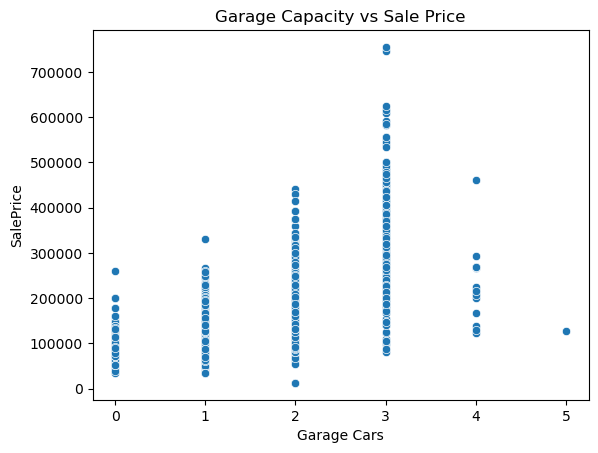

In [73]:
sns.scatterplot(
    data=df,
    x="Garage Cars",
    y="SalePrice"
)

plt.title("Garage Capacity vs Sale Price")

plt.show()

# Step 23: Basement Analysis

We investigate whether basement size contributes to higher property values.

In [74]:
basement_cols = [
    "Total Bsmt SF",
    "BsmtFin SF 1",
    "Bsmt Unf SF",
    "SalePrice"
]

df[basement_cols].corr()

,Total Bsmt SF,BsmtFin SF 1,Bsmt Unf SF,SalePrice
Total Bsmt SF,1.000000,0.536547,0.411726,0.632280
BsmtFin SF 1,0.536547,1.000000,-0.477875,0.432914
Bsmt Unf SF,0.411726,-0.477875,1.000000,0.182855
SalePrice,0.632280,0.432914,0.182855,1.000000


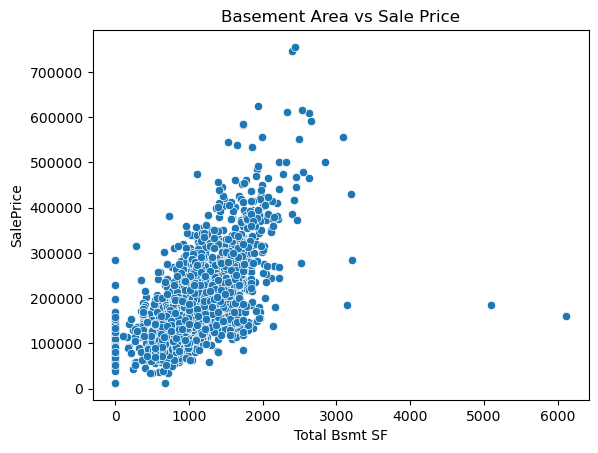

In [75]:
sns.scatterplot(
    data=df,
    x="Total Bsmt SF",
    y="SalePrice"
)

plt.title("Basement Area vs Sale Price")

plt.show()

# Step 24: Outlier Detection

Outliers may influence regression models and distort predictions.

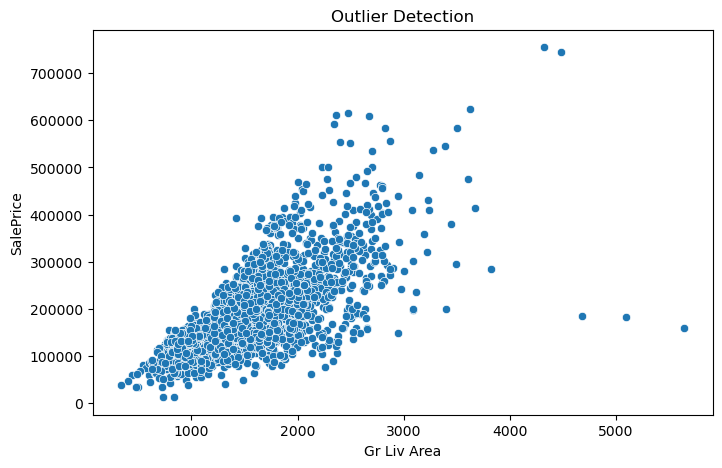

In [76]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Gr Liv Area",
    y="SalePrice"
)

plt.title("Outlier Detection")

plt.show()

In [77]:
outliers = df[
    (df["Gr Liv Area"] > 4000)
    &
    (df["SalePrice"] < 300000)
]

outliers

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,HighPrice
1498,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,Corner,...,Gd,NaN,NaN,0,1,2008,New,Partial,160000,0
2180,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,AllPub,Inside,...,NaN,NaN,Elev,17000,10,2007,New,Partial,183850,1
2181,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,Inside,...,NaN,NaN,NaN,0,10,2007,New,Partial,184750,1


# Step 25: Final Summary

This project included:

- Data preprocessing
- Missing value handling
- Feature encoding
- Feature scaling
- Regression modelling
- Classification modelling
- K-Means clustering
- DBSCAN clustering
- Feature importance analysis
- Housing market insights

The Ames Housing dataset successfully demonstrated supervised and unsupervised machine learning techniques on a real-world dataset.